# Beyond one number per material

The screening tutorial produced scalars: an energy, a distance above the hull, a
pass/fail. Plenty of results are not scalars. A diffraction pattern is a curve.
A force is one vector per atom, and the number of atoms differs from material to
material. A measurement is a number somebody took off an instrument rather than
out of a calculator.

This tutorial covers where each of those lives, and why.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

matverse 0.1.12 — 121 functions


## Loading a dataset

The same Al–Ni–Cu library as [Screening, end to end](screening.ipynb): three
elemental fcc metals at their published lattice parameters, four hypothetical
intermetallics.

In [2]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    return Structure(Lattice.cubic(a), [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


elemental = mv.datasets.metals(["Al", "Cu", "Ni"])
md = mv.data.from_structures(mv.structures(elemental) + [
    l12("Al", "Cu", 3.90), l12("Cu", "Al", 3.70), l12("Al", "Ni", 3.78),
    Structure(Lattice.cubic(2.89), ["Al", "Ni"], [[0, 0, 0], [.5, .5, .5]]),
])
mv.pp.describe(md)

md.obs[["formula", "nsites", "density"]].round(3)

,formula,nsites,density
0,Al,4,2.699
1,Cu,4,8.935
2,Ni,4,8.908
3,Al3Cu,4,4.045
4,AlCu3,4,7.134
5,Al3Ni,4,4.293
6,AlNi,2,5.894


## Curves live in `obsm` on a shared grid

pymatgen returns a peak list, and peak lists cannot be compared across materials
because no two share the same peak positions. Broadening each reflection onto a
common grid is what turns a set of patterns into a matrix — and a matrix is
something you can take a distance on, cluster, or subtract a measurement from.

In [3]:
mv.prop.xrd(md, two_theta=(10, 90), step=0.02, fwhm=0.1)

md.obsm["xrd_calc"].shape, mv.grid_of(md, "xrd").shape

((7, 4001), (4001,))

The block is named `'<quantity>_<level>'`, exactly like a scalar:

```
obs['energy_pbe']        a number per material, level in the suffix
obsm['xrd_pbe']          a curve per material, level in the suffix
obsm['xrd_experiment']   the same curve, measured
```

```{note}
This is one convention, not two. An earlier draft of the design had curves using
an AnnData `layer` for the level of theory while scalars used a name suffix, and
listed the split as a wart. Putting curves in `obsm` removed it — and removed
the need for MuData along with it, since a `materials × grid` matrix is aligned
to the material axis and that is what `obsm` is for.
```

The grid itself is stored once, in `uns`, because it is the one thing here that
is **not** aligned to the material axis:

In [4]:
md.uns["grids"]["xrd"]

{'values': array([10.  , 10.02, 10.04, ..., 89.96, 89.98, 90.  ], shape=(4001,)),
 'unit': 'degrees 2theta',
 'wavelength': 'CuKa',
 'fwhm': 0.1,
 'normalized': True}

Text(0.5, 1.0, 'Al, Al₃Cu, AlCu₃ — ordering adds superlattice reflections')

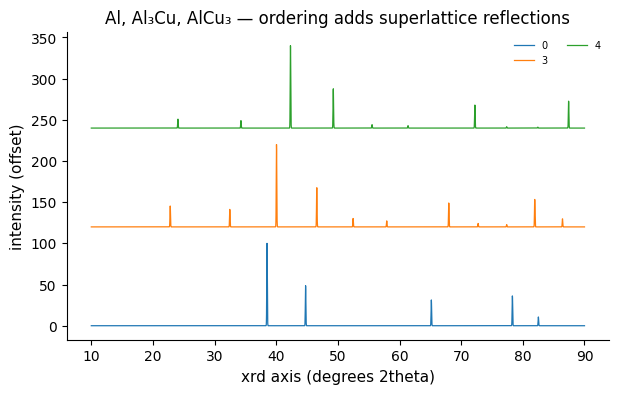

In [5]:
ax = mv.pl.spectra(md, "xrd", rows=[0, 3, 4], offset=120)
ax.set_title("Al, Al₃Cu, AlCu₃ — ordering adds superlattice reflections")

`mv.prop.rdf` is the other curve that ships, and it earns its place by doing
something composition cannot.

Text(0.5, 1.0, 'fcc Al against B2 AlNi')

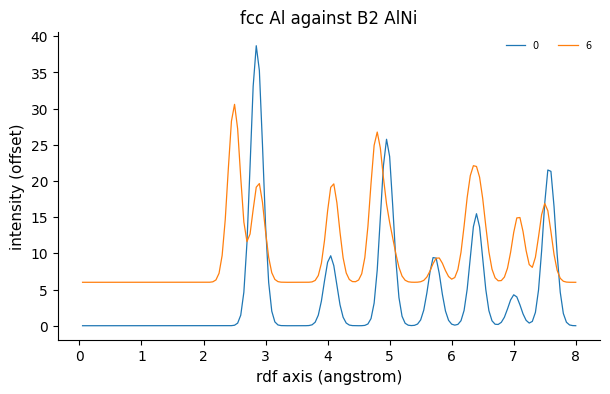

In [6]:
mv.prop.rdf(md, r_max=8.0)

ax = mv.pl.spectra(md, "rdf", rows=[0, 6], offset=6)
ax.set_title("fcc Al against B2 AlNi")

Two polymorphs have the same composition, so `X` cannot tell them apart and
neither can any composition descriptor. A radial distribution function can, and
unlike SOAP it needs no extra dependency.

## Per-atom results get their own axis

Forces are ragged. This library has 4, 4, 4, 4, 4, 4 and 2 atoms — 26 force
vectors, and no way to put them in a column of a seven-row table.

First, something to compute forces *on*. Every structure above is a perfect
cubic cell, and by symmetry the force on every atom in one is exactly zero — a
force example needs displaced atoms. `mv.pp.rattle` is how you make them, and
it is also how force-training sets for machine-learned potentials are built.

In [7]:
mv.pp.rattle(md, stdev=0.05, seed=0)
mv.variants(md)

['input', 'rattled']

In [8]:
sites = mv.multi.sites(md, source="rattled")
sites

AnnData object with n_obs × n_vars = 26 × 3
    obs: 'material', 'material_index', 'site_index', 'element'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'matverse_axis', 'parent', 'provenance'
    obsm: 'X_frac', 'X_cart'

In [9]:
sites.obs.head(8)

,material,material_index,site_index,element
0:0,0,0,0,Al
0:1,0,0,1,Al
0:2,0,0,2,Al
0:3,0,0,3,Al
1:0,1,1,0,Cu
1:1,1,1,1,Cu
1:2,1,1,2,Cu
1:3,1,1,3,Cu


One row per atom, with `obs['material']` pointing back at the parent. Per-atom
results are a matrix again.

In [10]:
mv.calc.forces(md, sites, level="emt", source="rattled")

sites.obsm["forces_emt"].shape

(26, 3)

In [11]:
sites.obs[["material", "element", "force_magnitude_emt"]].head(8).round(4)

,material,element,force_magnitude_emt
0:0,0,Al,0.1670
0:1,0,Al,0.1702
0:2,0,Al,0.3627
0:3,0,Al,0.2850
1:0,1,Cu,1.3463
1:1,1,Cu,0.7755
1:2,1,Cu,1.0314
1:3,1,Cu,1.2424


Text(0.5, 1.0, 'one point per atom, 26 in total')

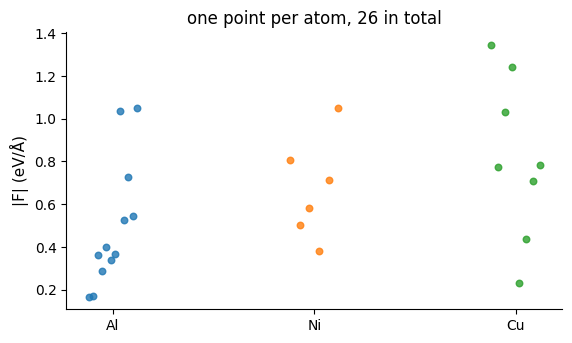

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for k, element in enumerate(sites.var_names):
    values = sites.obs.loc[sites.obs["element"] == element,
                           "force_magnitude_emt"]
    ax.scatter(np.full(len(values), k) + np.linspace(-0.12, 0.12, len(values)),
               values, s=22, alpha=0.8)
ax.set_xticks(range(sites.n_vars), list(sites.var_names))
ax.set_ylabel("|F| (eV/Å)")
ax.set_title("one point per atom, 26 in total")

Twenty-six points where the material axis has room for seven — which is the
whole reason the sites axis exists.

`mv.calc.forces` takes **both** objects, and the signature is honest about why:
forces need the structures, which live on the material axis, and produce one row
per atom, which lives on the sites axis.

```{warning}
The sites object is a snapshot of one structure variant. If you build it from
`'input'` and then ask for forces on `'relaxed_emt'`, the atoms will not line up
— so matverse refuses rather than silently misaligning them. Rebuild with
`mv.multi.sites(md, source='relaxed_emt')`.
```

### Getting back to the material axis

A per-site result is not screenable until it is summarised.

In [13]:
mv.multi.aggregate(sites, md, "force_magnitude_emt", how="max")

md.obs[["formula", "force_magnitude_emt_max"]].round(4)

,formula,force_magnitude_emt_max
0,Al,0.3627
1,Cu,1.3463
2,Ni,0.8071
3,Al3Cu,0.3973
4,AlCu3,1.0337
5,Al3Ni,0.7290
6,AlNi,1.0499


The largest force in each cell, on the material axis, where a screen can reach
it. A residual force is a useful convergence criterion: the cells that respond
least to being rattled are the ones sitting in the stiffest local minimum.

In [14]:
mv.screen.filter(md, force_magnitude_emt_max__lt=0.8, name="soft_response")
md.obs[["formula", "force_magnitude_emt_max", "soft_response"]].round(4)

,formula,force_magnitude_emt_max,soft_response
0,Al,0.3627,True
1,Cu,1.3463,False
2,Ni,0.8071,False
3,Al3Cu,0.3973,True
4,AlCu3,1.0337,False
5,Al3Ni,0.7290,True
6,AlNi,1.0499,False


The detail stays on the sites object where it can still be inspected; the
summary lands on the materials object where a screen can reach it.

### The element axis is shared

`sites.X` is the one-hot element indicator, so `sites.var` is the same periodic
table the parent carries. Everything written for element-level questions works
on atoms without modification.

In [15]:
forces = sites.obs["force_magnitude_emt"].to_numpy(dtype=float)
sites.obs["strained"] = forces > np.median(forces)
mv.tl.rank_elements_groups(sites, "strained")

sites.uns["rank_elements_groups"]["True"][
    ["element", "n_in_group", "frac_in_group", "odds_ratio", "pval"]]

,element,n_in_group,frac_in_group,odds_ratio,pval
0,Al,3,0.230769,0.133333,0.047180
1,Cu,6,0.461538,4.714286,0.201556
2,Ni,4,0.307692,2.444444,0.644720


That is `rank_genes_groups` answering "which elements sit in the highest-force
environments", and it needed no new function.

### One object, if you want one

```python
mdata = mv.multi.to_mudata(md, sites)     # needs matverse[multi]
```

Optional throughout. matverse's operations take `AnnData`, and the sites object
is useful without ever being assembled.

## Experiment is a level of theory

This needed no new machinery, which is the argument for having typed the level
of theory in the first place. Two calculated levels and one measured one, on the
same quantity:

In [16]:
mv.calc.energy(md, level="emt")
md.obs["energy_per_atom_shifted"] = \
    md.obs["energy_per_atom_emt"].to_numpy(dtype=float) - 0.05
mv.set_level(md, "shifted", kind="classical", method="EMT with an offset")

measured = md.obs["energy_per_atom_emt"].to_numpy(dtype=float) + 0.02
mv.exp.measure(md, "energy_per_atom", measured, instrument="calorimeter")

mv.compare_levels(md, "energy_per_atom").round(4)

,emt,experiment,shifted
0,-0.0016,0.0184,-0.0516
1,-0.0050,0.0150,-0.0550
2,-0.0076,0.0124,-0.0576
3,0.0796,0.0996,0.0296
4,0.1093,0.1293,0.0593
5,0.1829,0.2029,0.1329
6,0.4306,0.4506,0.3806


Three numbers, three levels, one table, and nobody had to decide which one is
"the" energy. `uns['levels']['experiment']` records the instrument where
`uns['levels']['emt']` records the method:

In [17]:
mv.level_info(md, "experiment")

{'kind': 'experiment',
 'method': 'calorimeter',
 'reference': None,
 'surrogate': False,
 'license': None,
 'uncertainty': None,
 'instrument': 'calorimeter'}

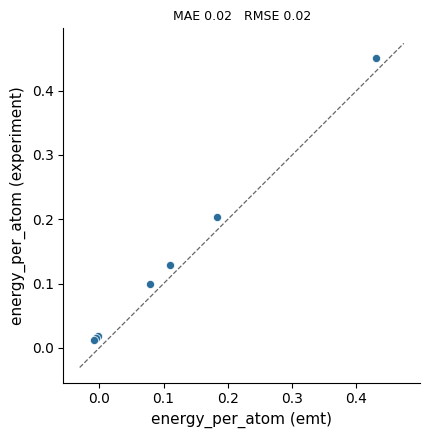

In [18]:
ax = mv.pl.parity(md, "energy_per_atom", "emt", "experiment")

`mv.pl.parity` annotates the error and — the useful bit — prints a warning on
the plot when the two levels reproduce different methods. A parity plot silently
comparing PBE against r2SCAN looks exactly like one comparing PBE against PBE.

### Phase identification

The compelling case is a measured pattern against a candidate library. Take the
Al₃Cu pattern, add noise and a sloping background, and hand it back as though it
came off an instrument.

In [19]:
rng = np.random.default_rng(0)
two_theta = mv.grid_of(md, "xrd")
observed = (md.obsm["xrd_calc"][3]
            + rng.normal(0, 0.5, two_theta.size)      # counting noise
            + 0.02 * two_theta)                        # sloping background

mv.exp.match_xrd(md, observed, two_theta)
md.obs[["formula", "xrd_match", "xrd_match_rank"]].sort_values("xrd_match_rank")

,formula,xrd_match,xrd_match_rank
3,Al3Cu,0.841538,1.0
5,Al3Ni,0.055221,2.0
4,AlCu3,0.046938,3.0
0,Al,0.043372,4.0
6,AlNi,0.038320,5.0
1,Cu,0.035837,6.0
2,Ni,0.035354,7.0


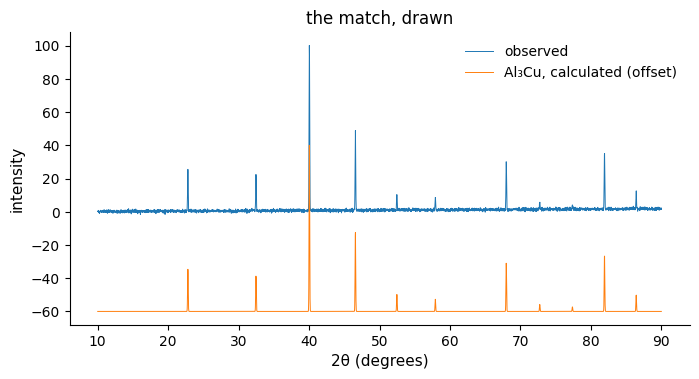

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(two_theta, observed, linewidth=0.7, label="observed")
ax.plot(two_theta, md.obsm["xrd_calc"][3] - 60, linewidth=0.7,
        label="Al₃Cu, calculated (offset)")
ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("intensity")
ax.set_title("the match, drawn")
ax.legend()

Both patterns are baseline-shifted and unit-normalised before the dot product,
so the score reflects peak positions and relative heights rather than exposure
time — which is why the sloping background above did not move the answer.

In [21]:
md.uns["xrd_match"]["best"], md.uns["xrd_match"]["scored_against"]

('3', "this object's candidates only")

```{warning}
`match_xrd` scores against the candidates in this object and nothing else, and
records that fact in `uns['xrd_match']['scored_against']`. A high score means
"the best of what you gave it", not "identified" — the true phase can be absent
from your library entirely.
```

### Attaching a full measured curve

A measurement usually covers a narrower range than the calculation, at its own
resolution. Simulate that: 20–70° on a coarser step.

In [22]:
instrument_grid = np.arange(20.0, 70.0, 0.05)
patterns = np.vstack([
    np.interp(instrument_grid, two_theta, row) + rng.normal(0, 0.3,
                                                            instrument_grid.size)
    for row in md.obsm["xrd_calc"]])

mv.exp.attach(md, "xrd", patterns, instrument_grid, instrument="Bruker D8")
mv.prop.compare_grids(md, "xrd", "calc", "experiment")

md.obs[["formula", "xrd_cosine_calc_vs_experiment",
        "xrd_overlap_calc_vs_experiment"]].round(3)

,formula,xrd_cosine_calc_vs_experiment,xrd_overlap_calc_vs_experiment
0,Al,0.994,2497.0
1,Cu,0.993,2497.0
2,Ni,0.993,2497.0
3,Al3Cu,0.993,2497.0
4,AlCu3,0.994,2497.0
5,Al3Ni,0.993,2497.0
6,AlNi,0.993,2497.0


Measurements are resampled onto the existing grid, because two curves on
different grids cannot be subtracted. Points outside the measured range become
NaN rather than zero, and the comparison runs over the overlap — `overlap` is
the **number of grid points** both curves cover. 2497 of the calculation's 4000
is the 20–70° the instrument saw, out of the 10–90° that was computed.

```{warning}
Attach a measurement at its own resolution or better. Diffraction peaks are
narrow, and resampling onto a grid coarser than the peak width discards them
permanently — no later interpolation brings them back. There is a test in the
suite pinning this behaviour so nobody "fixes" it.
```

## Reconciling databases

If your candidates came from more than one source, their energies are not
directly comparable. Materials Project, OQMD and Alexandria differ in
pseudopotentials, cutoffs and correction schemes, and the resulting offsets have
compositional structure — which makes them a batch effect.

Simulate one. Take every material **twice**, label one copy `mp` and the other
`oqmd`, and shift the `oqmd` copy by a per-element offset. The overlap matters:
harmonisation is a fit, and a fit needs compositions both databases contain.

In [23]:
both = mv.data.from_structures(mv.structures(md) * 2)
mv.pp.describe(both)
mv.pp.normalize_composition(both)
mv.calc.energy(both, level="emt")

offsets = np.array([{"Al": 0.10, "Ni": -0.06, "Cu": 0.03}[e]
                    for e in both.var_names])
shift = np.asarray(both.layers["fraction"].todense()) @ offsets

both.obs["database"] = ["mp"] * md.n_obs + ["oqmd"] * md.n_obs
both.obs["energy_per_atom_dft"] = (
    both.obs["energy_per_atom_emt"].to_numpy(dtype=float)
    + np.where(both.obs["database"] == "oqmd", shift, 0.0))

both.obs[["formula", "database", "energy_per_atom_dft"]].round(4)

,formula,database,energy_per_atom_dft
0,Al,mp,-0.0016
1,Cu,mp,-0.0050
2,Ni,mp,-0.0076
3,Al3Cu,mp,0.0796
4,AlCu3,mp,0.1093
5,Al3Ni,mp,0.1829
6,AlNi,mp,0.4306
7,Al,oqmd,0.0984
8,Cu,oqmd,0.0250
9,Ni,oqmd,-0.0676


In [24]:
mv.pp.harmonize(both, batch_key="database",
                energy_key="energy_per_atom_dft", reference="mp")

both.uns["harmonize"]["diagnostics"]["oqmd"]

{'n_anchors': 7,
 'n_elements_fitted': 3,
 'rmse_before': 0.06274950199005568,
 'rmse_after': 4.25323228084008e-17,
 'underdetermined': False}

The fitted offsets should recover the ones put in — 0.10, −0.06 and 0.03:

In [25]:
pd.Series(both.uns["harmonize"]["offsets"]["oqmd"],
          index=both.var_names, name="fitted offset").round(3)

element
Al    0.10
Ni   -0.06
Cu    0.03
Name: fitted offset, dtype: float64

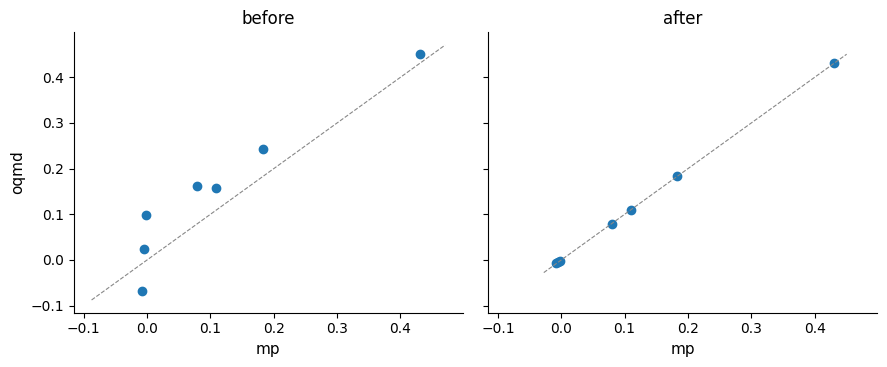

In [26]:
n = md.n_obs
raw = both.obs["energy_per_atom_dft"].to_numpy(dtype=float)
fixed = both.obs["energy_per_atom_dft_harmonized"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=True, sharey=True)
for ax, values, title in ((axes[0], raw, "before"), (axes[1], fixed, "after")):
    ax.scatter(values[:n], values[n:], s=36)
    lo, hi = values.min() - 0.02, values.max() + 0.02
    ax.plot([lo, hi], [lo, hi], "--", linewidth=0.8, color="#888")
    ax.set_xlabel("mp"); ax.set_title(title)
axes[0].set_ylabel("oqmd")
fig.tight_layout()

Same materials, two databases, plotted against each other. Before, they scatter
off the diagonal in a way that depends on composition; after, they land on it.

The model is the one the field already uses by hand — a per-element reference
offset — fitted by least squares on the compositions two databases share.

```{warning}
It cannot repair a disagreement that is not linear in composition. Two databases
that differ because one relaxed with a different functional will differ
structure by structure, and a compositional offset absorbs only the average of
that. Read `rmse_after`: it is what is left.

`harmonize` also warns and does nothing when the databases share no composition,
because with no anchors there is nothing to fit.
```

## Scoring generated candidates

Substitution within a known structure type is the cheap baseline every
generative model should be measured against — and is what several were found to
be doing implicitly.

In [27]:
generated = mv.gen.substitute(md, {"Al": ["Ga", "In"]}, charge_balanced=False)
mv.pp.describe(generated)

generated.obs[["formula", "parent", "substitution"]].head(8)

,formula,parent,substitution
0,Ga,0,Al->Ga
1,In,0,Al->In
2,Ga3Cu,3,Al->Ga
3,In3Cu,3,Al->In
4,GaCu3,4,Al->Ga
5,InCu3,4,Al->In
6,Ga3Ni,5,Al->Ga
7,In3Ni,5,Al->In


In [28]:
mv.gen.validate(generated, reference=md)

generated.uns["gen_validate"]["rates"]

{'valid': 1.0,
 'unique': 1.0,
 'novel': 1.0,
 'stable': None,
 'sun': None,
 'msun': None}

Validity, uniqueness, novelty and stability use LeMat-GenBench's definitions
rather than a variant, and every parameter is recorded next to the rates:

In [29]:
generated.uns["gen_validate"]["definitions"]

{'min_distance': 0.5,
 'stability_threshold': 0.0,
 'metastability_threshold': 0.1,
 'ltol': 0.2,
 'stol': 0.3,
 'angle_tol': 5.0,
 'source': 'input',
 'level': None,
 'reference': '7 structures',
 'novelty_means': 'absent from the named reference set under StructureMatcher at the stated tolerances',
 'metric_family': 'LeMat-GenBench (arXiv:2512.04562) definitions'}

That matters more than it looks. Until those definitions were pinned, the same
metric name meant different things depending on which reference set, stability
threshold and matching tolerance a paper used — so the numbers were not
comparable even when the names were identical.

```{warning}
Stability is reported as **not assessed** rather than zero when no level is
given or when the hull was built over the dataset's own compositions. A closed
hull cannot say whether anything is stable.
```

In [30]:
generated.uns["gen_validate"]["not_assessed"]

{'stability': 'no level was given, so stability was not assessed'}

Novelty means "absent from the reference set you named", which is a weaker claim
than it sounds. A 2026 stress test found that neither MatterGen nor DiffCSP++
recovered the experimentally observed structures of the newly synthesised
GdNiSn₄ and LuNiSn₄, despite both being built from known motifs — current models
recombine compositions within known structural families. A high novelty rate
measured against a database does not contradict that.

```{seealso}
[Models and campaigns](models_and_campaigns.ipynb) covers the other half:
predicting what you have not computed, and choosing what to compute next.
```